In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Defining Global Variable

In [3]:
x_star = 1/3 * (-2 + np.cbrt(19-3*np.sqrt(33)) + np.cbrt(19+3*np.sqrt(33)))
theta = np.arcsin(x_star)

# Graphing Settings

In [4]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Defining Numpy Matrices

In [5]:
identity = np.array([[1,0], [0,1]])
ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])

# Infidelity to Error Rates

In [46]:
def inf_to_error(infidelity_list):
    error_rates_list = []
    alpha_star = np.sqrt((1-x_star)/2)
    beta_star = -np.sqrt((1+x_star)/2)
    noisy_ket = alpha_star * np.array([[1],[0]]) + beta_star * np.array([[0],[1]])
    target_ket = ry_theta @ np.array([[1],[0]])
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity / (1 - np.abs(np.vdot(target_ket, noisy_ket))**2) )
    
    return error_rates_list

In [7]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [8]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations

In [54]:
input_error_rate_list = np.linspace(0.01,0.5, 500)

Consider the case when only state preparation is noisy

In [55]:
ideal = QuantumCircuit(2)
ideal.ry(theta,0)
ideal_dm = DensityMatrix(ideal)

In [56]:
alpha_star = np.sqrt((1-x_star)/2)
beta_star = -np.sqrt((1+x_star)/2)
ket_bar = alpha_star * np.array([[1],[0]]) + beta_star * np.array([[0],[1]])

def kraus0(error_prob):
    return np.sqrt(1-error_prob) * np.eye(2)
def kraus1(error_prob):
    return np.sqrt(error_prob) * np.matmul(ket_bar, np.array([[1,0]]))
def kraus2(error_prob):
    return np.sqrt(error_prob) * np.matmul(ket_bar, np.array([[0,1]]))

In [57]:
shots = 50

# Store the output infidelity.
infidelity_list = []

for err in input_error_rate_list:
    prep = ry_theta @ np.matmul([[1],[0]], [[1,0]]) @ ry_theta.conj().T
    rho_in = kraus0(err) @ prep @ kraus0(err).conj().T + kraus1(err) @ prep @ kraus1(err).conj().T + kraus2(err) @ prep @ kraus2(err).conj().T
    rho_in = rho_in / np.trace(rho_in)
    
    # Building the input density matrix
    rho_two = DensityMatrix(np.kron(rho_in.data, rho_in.data))
    meas_circuit = QuantumCircuit(2, 1)
    meas_circuit.append(SetDensityMatrix(rho_two), meas_circuit.qubits)

    # Two-qubit distillation protocol
    meas_circuit.cx(0, 1)
    meas_circuit.h(0)
    meas_circuit.measure([1], [0])

    # Measure for post-selection and save the conditional density matrix.
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label="dm_post",
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )

    # Run the density-matrix simulation.
    noise_model = NoiseModel()
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()
    
    # Compute the accepted output infidelity.
    res_dm = result.data()['dm_post']
    rho_post_2q = res_dm["0x0"][0]
    infidelity_list.append(1 - state_fidelity(rho_post_2q, ideal_dm))
output_error_rate = inf_to_error(infidelity_list)

In [59]:
# Finding the intersection of the curve with y=x
y = output_error_rate
x = input_error_rate_list

diff = y - x

# Find where the sign changes
idx = np.where(diff[:-1] * diff[1:] <= 0)[0][0]

# Interpolate intersection in log-log space
logx1, logx2 = np.log(x[idx]), np.log(x[idx + 1])
logy1, logy2 = np.log(y[idx]), np.log(y[idx + 1])

# Interpolate log(output/input)
f1 = logy1 - logx1
f2 = logy2 - logx2

logx_intersect = logx1 - f1 * (logx2 - logx1) / (f2 - f1)
x_intersect = np.exp(logx_intersect)
y_intersect = x_intersect

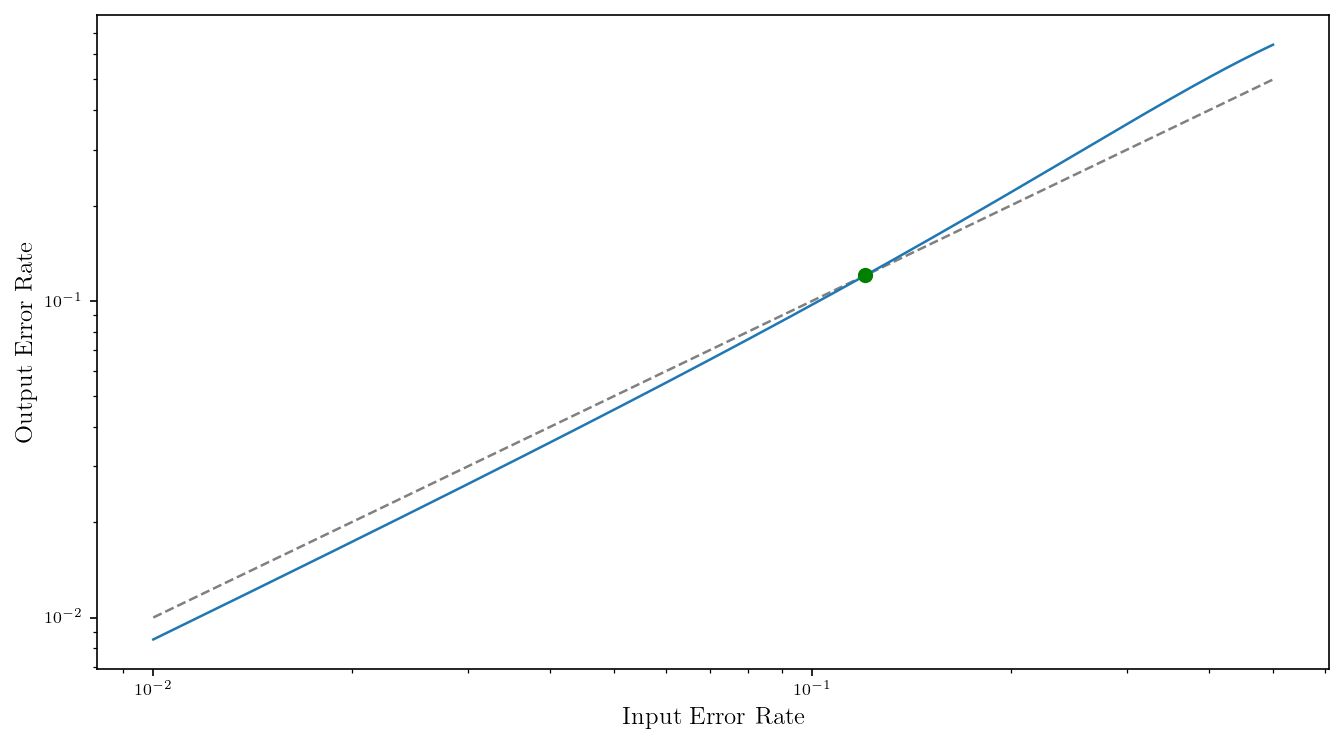

In [60]:
plt.figure(figsize=(9, 5))

plt.plot(input_error_rate_list, input_error_rate_list, color="gray", linestyle="--")
plt.plot(input_error_rate_list, output_error_rate)
plt.scatter(x_intersect, y_intersect, color="green", s=40, zorder=5,)
plt.xlabel("Input Error Rate", fontsize=12)
plt.ylabel("Output Error Rate", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [61]:
print(x_intersect)

0.12036323574334075
